In [ ]:
#Data Generation

In [10]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 5000

data = pd.DataFrame({
    "user_id" : range(n),
    "group" : np.random.choice(["A","B"],n),
    "user_type" : np.random.choice(["new","returning"],n , p=[0.6,0.4]),
    "device": np.random.choice(["mobile","desktop"] , n , p =[0.7,0.3]),
    "traffic_source" : np.random.choice(["ads","organic"], n),
    "date": pd.date_range(start = "2024-01-01", periods=n, freq="H")
})

data["converted"] = data.apply( 
    lambda row: np.random.binomial(1,0.10 if row["group"] == "A"
                                   else 0.14 if row["user_type"] == "new" 
                                   else 0.09),
    axis =1 )

data["revenue"] = data["converted"] * np.random.randint(500,3000,n)

data.head()

C:\Users\15501\AppData\Local\Temp\ipykernel_20436\3913443835.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "date": pd.date_range(start = "2024-01-01", periods=n, freq="H")


,user_id,group,user_type,device,traffic_source,date,converted,revenue
0,0,A,returning,mobile,ads,2024-01-01 00:00:00,0,0
1,1,B,returning,desktop,organic,2024-01-01 01:00:00,0,0
2,2,A,new,mobile,ads,2024-01-01 02:00:00,0,0
3,3,A,returning,mobile,organic,2024-01-01 03:00:00,0,0
4,4,A,new,mobile,organic,2024-01-01 04:00:00,0,0


In [ ]:
#Data Cleaning

In [11]:
print(data.isnull().sum())
print(data.duplicated().sum())

user_id           0
group             0
user_type         0
device            0
traffic_source    0
date              0
converted         0
revenue           0
dtype: int64
0


Insight : No missing or duplicate values detected, indicating clean dataset.

In [ ]:
#Sample Ratio Checks

In [12]:
data["group"].value_counts(normalize = True)

group
A    0.5008
B    0.4992
Name: proportion, dtype: float64

Insight: The distribution between A and B groups is approximately , equal , confirming no sample ratio mismatch

In [ ]:
#Exploratory Data Analysis[EDA]

In [13]:
print(data["device"].value_counts())
data["traffic_source"].value_counts()

device
mobile     3524
desktop    1476
Name: count, dtype: int64


traffic_source
organic    2515
ads        2485
Name: count, dtype: int64

Insight: Majority of users are on mobile devices, and traffic is evenly distributed between ads and organic.

In [14]:
#Conversion Rate Analysis

In [15]:
conversion = data.groupby("group")["converted"].mean()
print(conversion)

group
A    0.103834
B    0.125801
Name: converted, dtype: float64


Insight: Version B shows a higher conversion rate compared to version A, indicating a potential improvement in user experience with the new checkout flow.

In [16]:
#Statistical Significance Testing (T-Test)

In [17]:
from scipy.stats import ttest_ind

group_a = data[data["group"] == "A"]["converted"]
group_b = data[data["group"] == "B"]["converted"]

t_stat,p_value = ttest_ind(group_a,group_b)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -2.4373216766930046
P-value: 0.014831151993439769


Insight: The p-value is less than 0.05, which indicate that the observed difference in conversion rates is statistically significant and not due to random chances.

In [18]:
#Effect Size

In [32]:
effect_B = conversion["B"] - conversion["A"]
print(effect_B)

0.02196741623658556


In [20]:
#Segmentation Analysis

In [21]:
segmentation = data.groupby(["group","user_type"])["converted"].mean()
print(segmentation)

group  user_type
A      new          0.096966
       returning    0.114372
B      new          0.148028
       returning    0.089568
Name: converted, dtype: float64


Insight: While version B improves conversion rate for new users, it negatively impacrs returning users. This highlights the importance of segmentation in A/B Testing.

In [22]:
#Device-Level Analysis

In [23]:
device_seg = data.groupby(["group","device"])["converted"].mean()
print(device_seg)

group  device 
A      desktop    0.094560
       mobile     0.107968
B      desktop    0.127841
       mobile     0.125000
Name: converted, dtype: float64


In [24]:
#Revenue Impact

In [25]:
revenue = data.groupby("group")["revenue"].mean()
print(revenue)

group
A    181.506789
B    228.291266
Name: revenue, dtype: float64


Insight: Version B lends to slight increase in average revenue per user, suggesting a positive business impact.

In [26]:
#Visualization

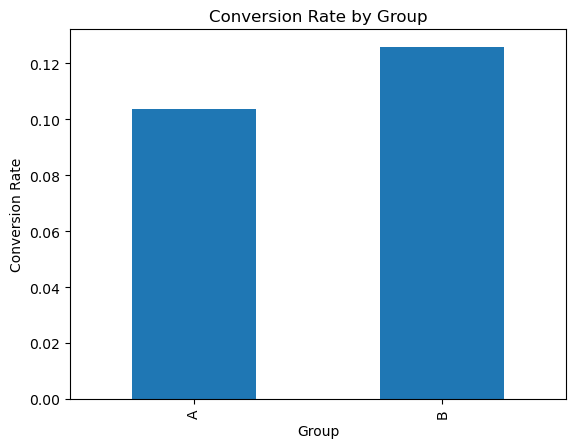

In [27]:
import matplotlib.pyplot  as plt

data.groupby("group")["converted"].mean().plot(kind="bar")
plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()

Insight : The visualization clearly shows that version B outperforms Version A in terms of conversion rates, reinforcing earlier findings.

In [28]:
#Saving Dataset

In [29]:
data.to_csv("ab_test_data.csv", index = False)

In [34]:
import os 
os.getcwd()

'C:\\Users\\15501'